# DQN baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import DQN_QNetwork


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


[DQN] step=   1000 | eps=0.981 | eval_return=0.250 | eval_len=376.0
[DQN] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0
[DQN] step=   3000 | eps=0.943 | eval_return=0.125 | eval_len=437.6
[DQN] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0
[DQN] step=   5000 | eps=0.905 | eval_return=0.125 | eval_len=437.6
[DQN] step=   6000 | eps=0.886 | eval_return=0.125 | eval_len=438.0
[DQN] step=   7000 | eps=0.867 | eval_return=0.500 | eval_len=252.4
[DQN] step=   8000 | eps=0.848 | eval_return=0.125 | eval_len=438.8
[DQN] step=   9000 | eps=0.829 | eval_return=0.000 | eval_len=500.0
[DQN] step=  10000 | eps=0.810 | eval_return=0.250 | eval_len=376.1
[DQN] step=  11000 | eps=0.791 | eval_return=0.000 | eval_len=500.0
[DQN] step=  12000 | eps=0.772 | eval_return=0.125 | eval_len=437.9
[DQN] step=  13000 | eps=0.753 | eval_return=0.000 | eval_len=500.0
[DQN] step=  14000 | eps=0.734 | eval_return=0.000 | eval_len=500.0
[DQN] step=  15000 | eps=0.715 | eval_return=0.0

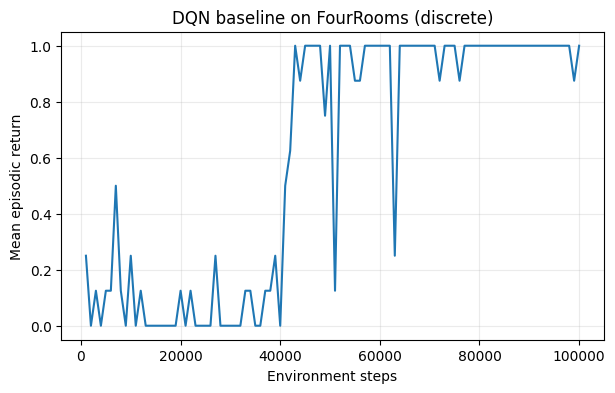

In [3]:
BUFFER_CAPACITY=100000
GOAL=(9, 9)
LR= float(1e-3)

env = make_env(goal=GOAL)
obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

q_net = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)



def dqn_train(q_network=q_net, q_target_network=q_target, env=env, buffer_capacity=BUFFER_CAPACITY, lr=LR, obs_dim=obs_dim, device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
    goal=GOAL,
    params= q_net.parameters()
):
    
    opt = optim.Adam(params, lr=lr)
    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []

    ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = [], [], [], [], [], []

    while global_step < total_steps:
        # Epsilon-greedy action selection
        frac = min(1.0, global_step / eps_decay_steps)
        eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                action = int(q_network(obs_t).argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        ep_obs.append(obs.copy())
        ep_actions.append(action)
        ep_rewards.append(float(rew))
        ep_next_obs.append(next_obs.copy())
        ep_terminated.append(float(term))
        ep_truncated.append(float(trunc))

        obs = next_obs
        global_step += 1

        if done:
            episode = {
                'obs': ep_obs,
                'actions': ep_actions,
                'rewards': ep_rewards,
                'next_obs': ep_next_obs,
                'terminated': ep_terminated,
                'truncated': ep_truncated,
            }
            buffer.add_episode(episode)
            ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = [], [], [], [], [], []
            obs, _ = env.reset()

        # Training update
        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()  # cast to int64 for use as gather indices
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated

            with torch.no_grad():
                next_q = q_target_network(next_obs_t).max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - term_t) * next_q

            current_q = q_network(obs_t).gather(1, act_t.unsqueeze(1))
            loss = F.mse_loss(current_q, target)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            # Soft update target network
            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: int(
                    q_network(
                        torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    ).argmax(dim=-1).item()
                ),
                episodes=8,
            )
            eval_returns.append((global_step, mean_ret))
            print(f'[DQN] step={global_step:7d} | eps={eps:.3f} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return q_network, eval_returns


dqn_q_first, dqn_eval_first = dqn_train()

if dqn_eval_first:
    xs, ys = zip(*dqn_eval_first)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete)')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 11 steps | return: 1.00 | reached goal: True
Episode 2: 6 steps | return: 1.00 | reached goal: True
Episode 3: 2 steps | return: 1.00 | reached goal: True
Episode 4: 16 steps | return: 1.00 | reached goal: True
Episode 5: 10 steps | return: 1.00 | reached goal: True
Episode 6: 12 steps | return: 1.00 | reached goal: True
Episode 7: 9 steps | return: 1.00 | reached goal: True
Episode 8: 12 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


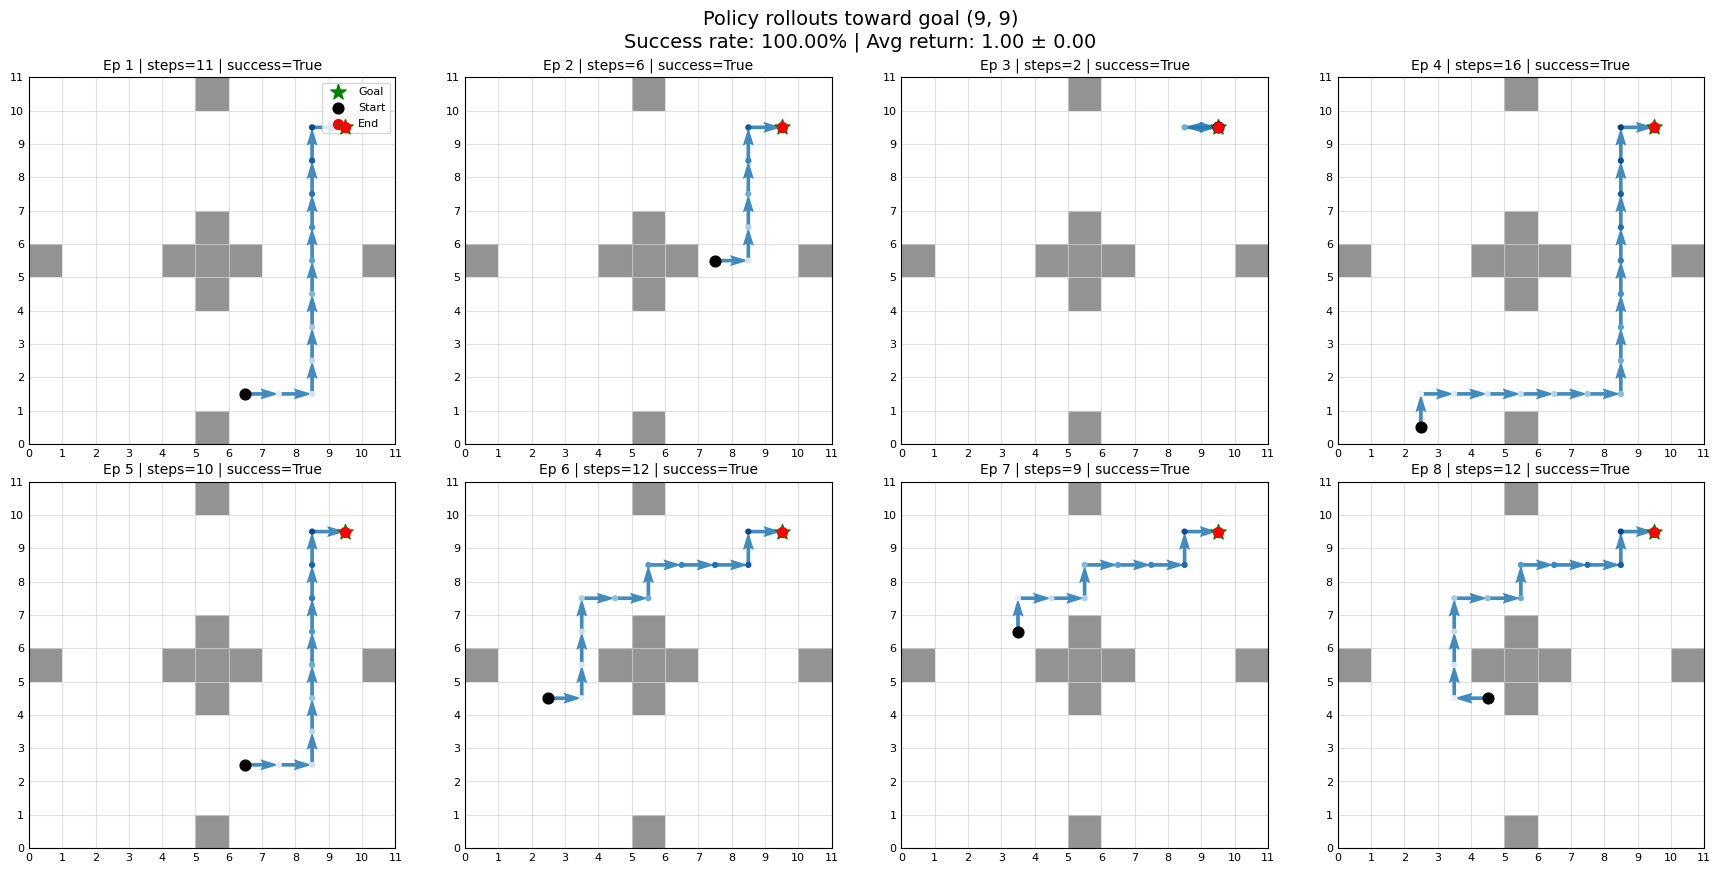

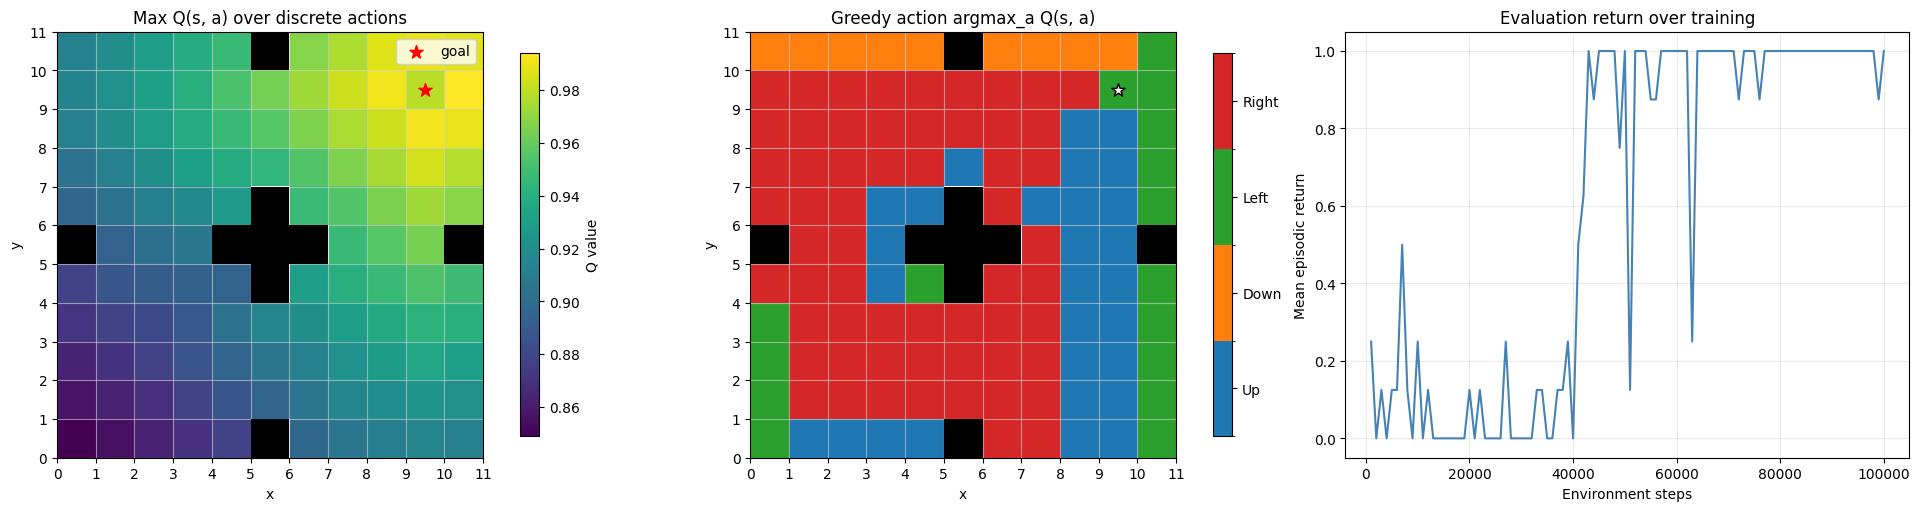

DQN_QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [4]:

dqn_q_first.eval()
eval_env_first = make_env(goal=(9, 9))


def dqn_policy_fn(obs,q_network):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = int(q_network(obs_t).argmax(dim=-1).item())
    return action


def dqn_value_fn(obs_batch, q_network):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        q_vals = q_network(obs_t).cpu().numpy()
    return q_vals


plot_policy_rollouts(
    env=eval_env_first,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_first),
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env_first.close()

eval_env_first = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env_first,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_first),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=(9, 9),
    eval_returns=dqn_eval_first,
)

eval_env_first.close()

dqn_q_first.train()


## Now to check how much samples needed to reach a new goal

[DQN] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=500.0
[DQN] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0
[DQN] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0
[DQN] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0
[DQN] step=   5000 | eps=0.905 | eval_return=0.125 | eval_len=437.6
[DQN] step=   6000 | eps=0.886 | eval_return=0.000 | eval_len=500.0
[DQN] step=   7000 | eps=0.867 | eval_return=0.000 | eval_len=500.0
[DQN] step=   8000 | eps=0.848 | eval_return=0.125 | eval_len=438.6
[DQN] step=   9000 | eps=0.829 | eval_return=0.125 | eval_len=438.0
[DQN] step=  10000 | eps=0.810 | eval_return=0.000 | eval_len=500.0
[DQN] step=  11000 | eps=0.791 | eval_return=0.125 | eval_len=437.9
[DQN] step=  12000 | eps=0.772 | eval_return=0.375 | eval_len=313.6
[DQN] step=  13000 | eps=0.753 | eval_return=0.000 | eval_len=500.0
[DQN] step=  14000 | eps=0.734 | eval_return=0.000 | eval_len=500.0
[DQN] step=  15000 | eps=0.715 | eval_return=0.2

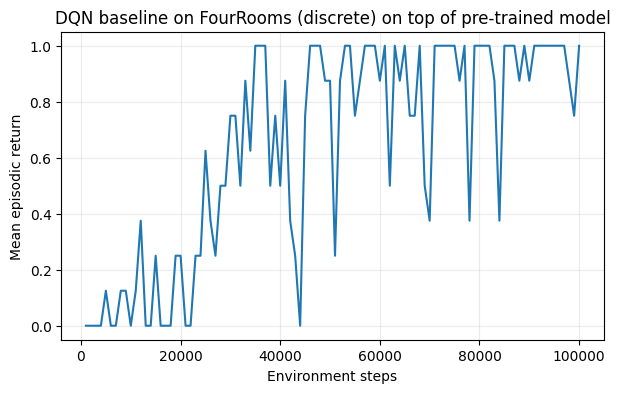

In [5]:
NEW_GOAL = (9, 1)

new_env = make_env(goal=NEW_GOAL)

q_target_new = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target_new.load_state_dict(q_net.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

for p in q_net.parameters():
    p.requires_grad_(False)

for p in q_net.net[-1].parameters():
    p.requires_grad_(True)


dqn_q_new, dqn_eval_new = dqn_train(env=new_env, q_network=dqn_q_first, q_target_network=q_target_new,goal=NEW_GOAL, params=q_net.net[-1].parameters())

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete) on top of pre-trained model')
    plt.grid(alpha=0.25)
    plt.show()


Episode 1: 3 steps | return: 1.00 | reached goal: True
Episode 2: 6 steps | return: 1.00 | reached goal: True
Episode 3: 11 steps | return: 1.00 | reached goal: True
Episode 4: 10 steps | return: 1.00 | reached goal: True
Episode 5: 12 steps | return: 1.00 | reached goal: True
Episode 6: 10 steps | return: 1.00 | reached goal: True
Episode 7: 3 steps | return: 1.00 | reached goal: True
Episode 8: 12 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


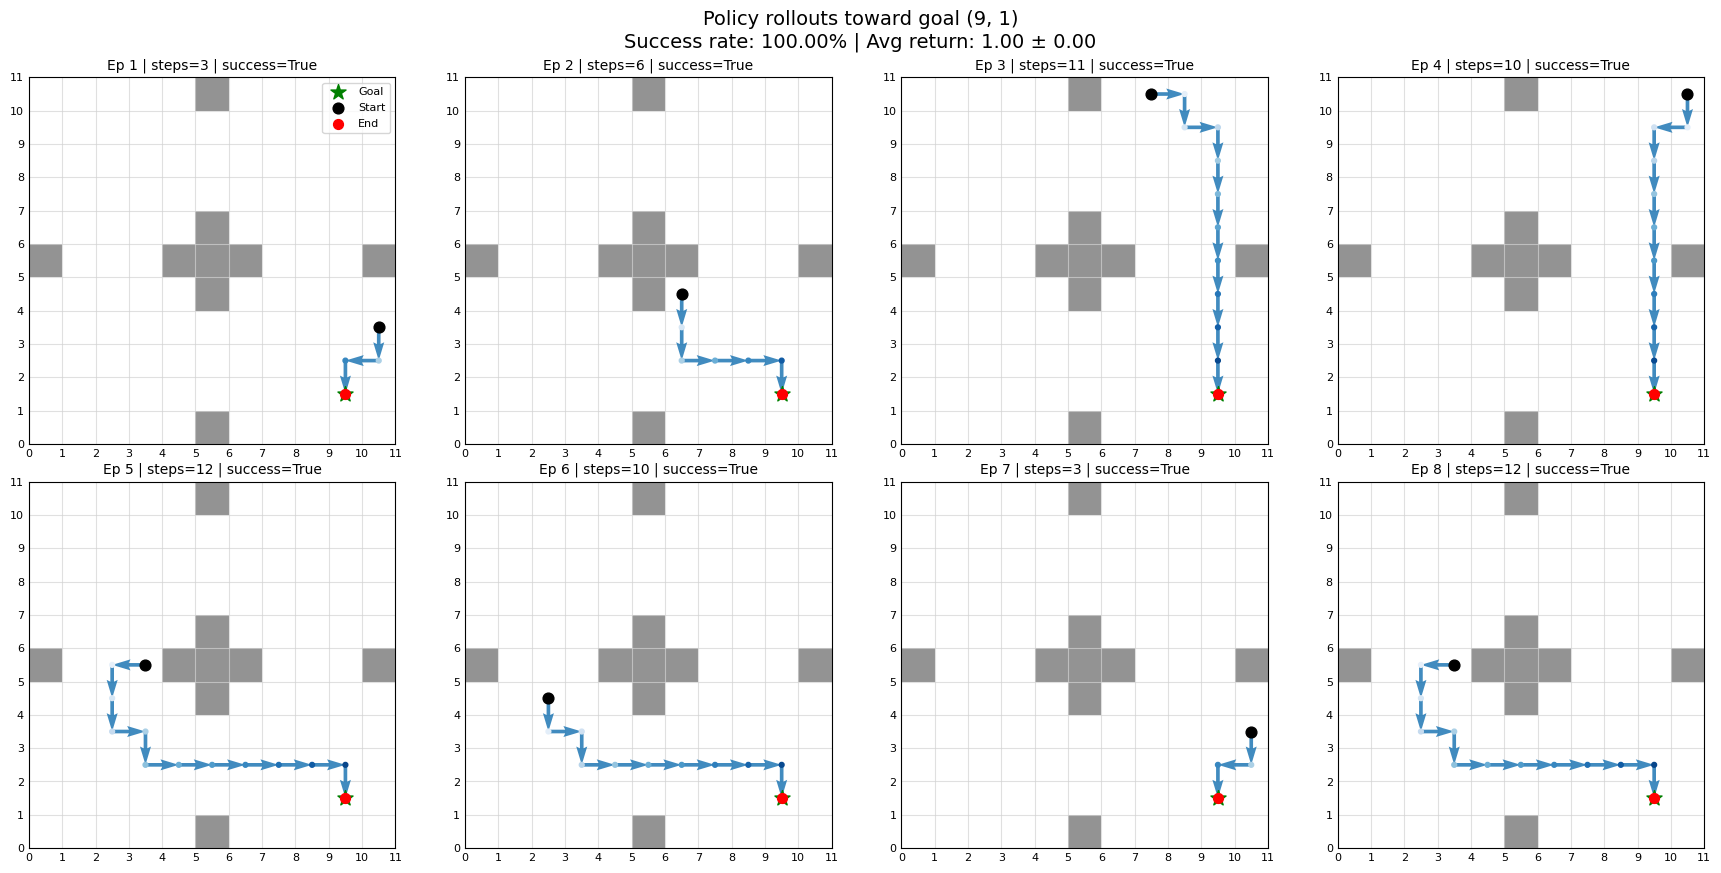

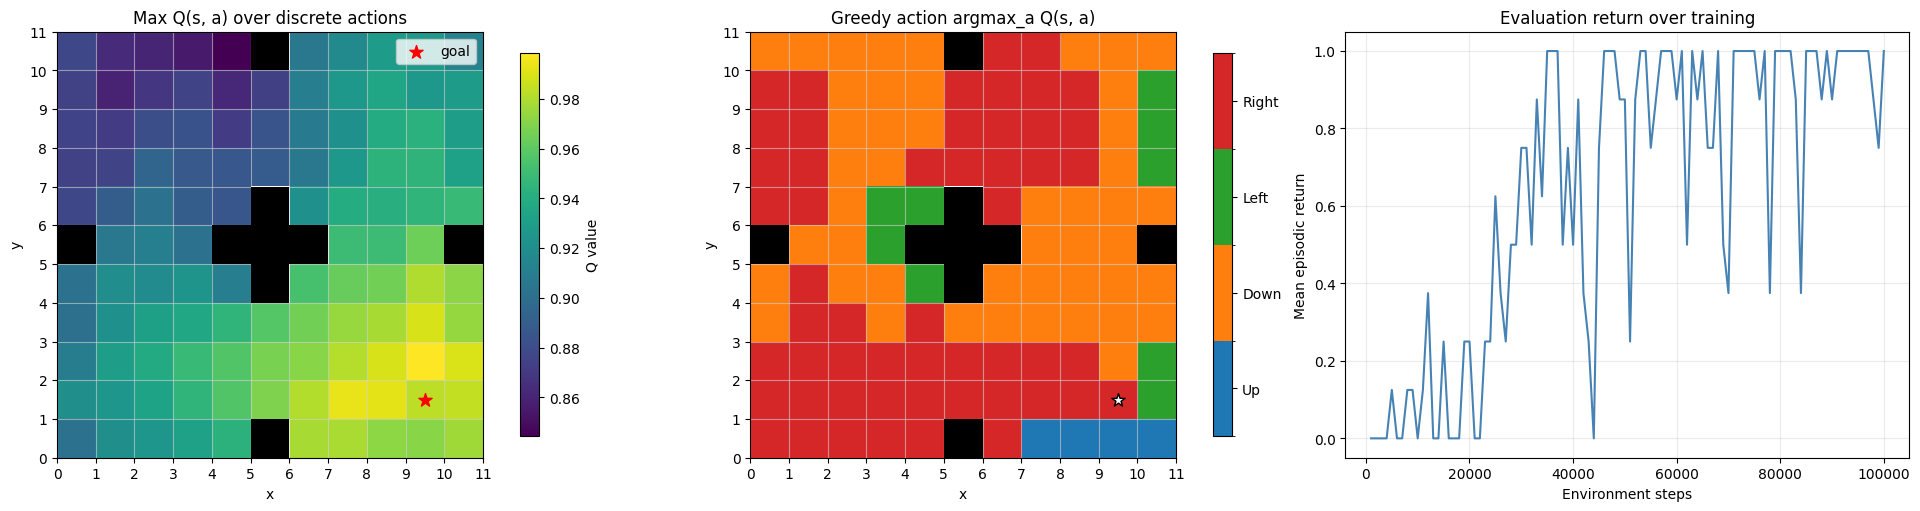

In [6]:

dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()


In [ ]:
# import copy
# import matplotlib.pyplot as plt


# def first_step_reaching_threshold(eval_returns, threshold=0.8, require_consecutive=1):
#     """
#     eval_returns: list of (global_step, mean_return)
#     threshold: success threshold on mean episodic return
#     require_consecutive: number of consecutive eval points that must meet threshold
#     """
#     if len(eval_returns) == 0:
#         return None

#     streak = 0
#     for step, value in eval_returns:
#         if value >= threshold:
#             streak += 1
#             if streak >= require_consecutive:
#                 return step
#         else:
#             streak = 0

#     return None


# def summarize_run(name, eval_returns, threshold=0.8, require_consecutive=1):
#     hit_step = first_step_reaching_threshold(
#         eval_returns,
#         threshold=threshold,
#         require_consecutive=require_consecutive,
#     )

#     print(f"\n{name}")
#     print("-" * len(name))
#     print(f"number of eval points: {len(eval_returns)}")

#     if len(eval_returns) > 0:
#         print(f"final eval return: {eval_returns[-1][1]:.3f}")

#     if hit_step is None:
#         print(f"did not reach threshold {threshold:.2f}")
#     else:
#         print(f"first reached threshold {threshold:.2f} at step {hit_step}")

#     return hit_step


# NEW_GOAL = (9, 1)
# TOTAL_STEPS = 100000
# THRESHOLD = 0.8
# REQUIRE_CONSECUTIVE = 1


# # ------------------------------------------------------------
# # Scratch run on the new goal
# # ------------------------------------------------------------
# scratch_env = make_env(goal=NEW_GOAL)

# scratch_q_net = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
# scratch_q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
# scratch_q_target.load_state_dict(scratch_q_net.state_dict())
# for p in scratch_q_target.parameters():
#     p.requires_grad_(False)

# scratch_q_net, scratch_eval_returns = dqn_train(
#     env=scratch_env,
#     q_network=scratch_q_net,
#     q_target_network=scratch_q_target,
#     total_steps=TOTAL_STEPS,
# )

# scratch_hit_step = summarize_run(
#     "Scratch on new goal",
#     scratch_eval_returns,
#     threshold=THRESHOLD,
#     require_consecutive=REQUIRE_CONSECUTIVE,
# )


# # ------------------------------------------------------------
# # Transfer run on the same new goal
# # ------------------------------------------------------------
# transfer_env = make_env(goal=NEW_GOAL)

# transfer_q_net = copy.deepcopy(dqn_q_first).to(DEVICE)
# transfer_q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
# transfer_q_target.load_state_dict(transfer_q_net.state_dict())
# for p in transfer_q_target.parameters():
#     p.requires_grad_(False)

# transfer_q_net, transfer_eval_returns = dqn_train(
#     env=transfer_env,
#     q_network=transfer_q_net,
#     q_target_network=transfer_q_target,
#     total_steps=TOTAL_STEPS,
# )

# transfer_hit_step = summarize_run(
#     "Transfer on new goal",
#     transfer_eval_returns,
#     threshold=THRESHOLD,
#     require_consecutive=REQUIRE_CONSECUTIVE,
# )


# # ------------------------------------------------------------
# # Sample comparison
# # ------------------------------------------------------------
# print("\nSample-efficiency comparison")
# print("----------------------------")

# if scratch_hit_step is None:
#     print("Scratch did not reach the threshold.")
# if transfer_hit_step is None:
#     print("Transfer did not reach the threshold.")

# if scratch_hit_step is not None and transfer_hit_step is not None:
#     extra_samples = scratch_hit_step - transfer_hit_step

#     print(f"scratch hit step:  {scratch_hit_step}")
#     print(f"transfer hit step: {transfer_hit_step}")

#     if extra_samples > 0:
#         print(f"Scratch needed {extra_samples} more samples than transfer.")
#     elif extra_samples < 0:
#         print(f"Transfer needed {-extra_samples} more samples than scratch.")
#     else:
#         print("Both reached the threshold at the same step.")


# # ------------------------------------------------------------
# # Plot learning curves
# # ------------------------------------------------------------
# plt.figure(figsize=(8, 5))

# if len(scratch_eval_returns) > 0:
#     xs, ys = zip(*scratch_eval_returns)
#     plt.plot(xs, ys, marker='o', label='Scratch')

# if len(transfer_eval_returns) > 0:
#     xs, ys = zip(*transfer_eval_returns)
#     plt.plot(xs, ys, marker='o', label='Transfer')

# plt.axhline(THRESHOLD, linestyle='--', color='black', alpha=0.7, label=f'Threshold = {THRESHOLD:.2f}')

# if scratch_hit_step is not None:
#     plt.axvline(scratch_hit_step, linestyle=':', color='tab:blue', alpha=0.7)

# if transfer_hit_step is not None:
#     plt.axvline(transfer_hit_step, linestyle=':', color='tab:orange', alpha=0.7)

# plt.xlabel('Environment steps')
# plt.ylabel('Mean episodic return')
# plt.title(f'Scratch vs transfer on new goal {NEW_GOAL}')
# plt.grid(alpha=0.25)
# plt.legend()
# plt.show()

ValueError: optimizer got an empty parameter list

[DQN] step=   1000 | eps=0.981 | eval_return=0.375 | eval_len=313.9
[DQN] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0
[DQN] step=   3000 | eps=0.943 | eval_return=0.250 | eval_len=376.2
[DQN] step=   4000 | eps=0.924 | eval_return=0.250 | eval_len=375.8
[DQN] step=   5000 | eps=0.905 | eval_return=0.125 | eval_len=437.6
[DQN] step=   6000 | eps=0.886 | eval_return=0.000 | eval_len=500.0
[DQN] step=   7000 | eps=0.867 | eval_return=0.000 | eval_len=500.0
[DQN] step=   8000 | eps=0.848 | eval_return=0.125 | eval_len=437.8
[DQN] step=   9000 | eps=0.829 | eval_return=0.500 | eval_len=251.1
[DQN] step=  10000 | eps=0.810 | eval_return=0.000 | eval_len=500.0
[DQN] step=  11000 | eps=0.791 | eval_return=0.125 | eval_len=438.0
[DQN] step=  12000 | eps=0.772 | eval_return=0.125 | eval_len=438.1
[DQN] step=  13000 | eps=0.753 | eval_return=0.125 | eval_len=438.1
[DQN] step=  14000 | eps=0.734 | eval_return=0.250 | eval_len=375.8
[DQN] step=  15000 | eps=0.715 | eval_return=0.1

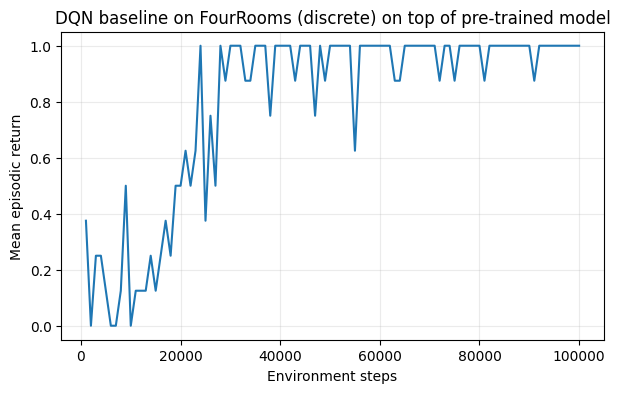

Episode 1: 11 steps | return: 1.00 | reached goal: True
Episode 2: 13 steps | return: 1.00 | reached goal: True
Episode 3: 4 steps | return: 1.00 | reached goal: True
Episode 4: 12 steps | return: 1.00 | reached goal: True
Episode 5: 3 steps | return: 1.00 | reached goal: True
Episode 6: 9 steps | return: 1.00 | reached goal: True
Episode 7: 10 steps | return: 1.00 | reached goal: True
Episode 8: 6 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


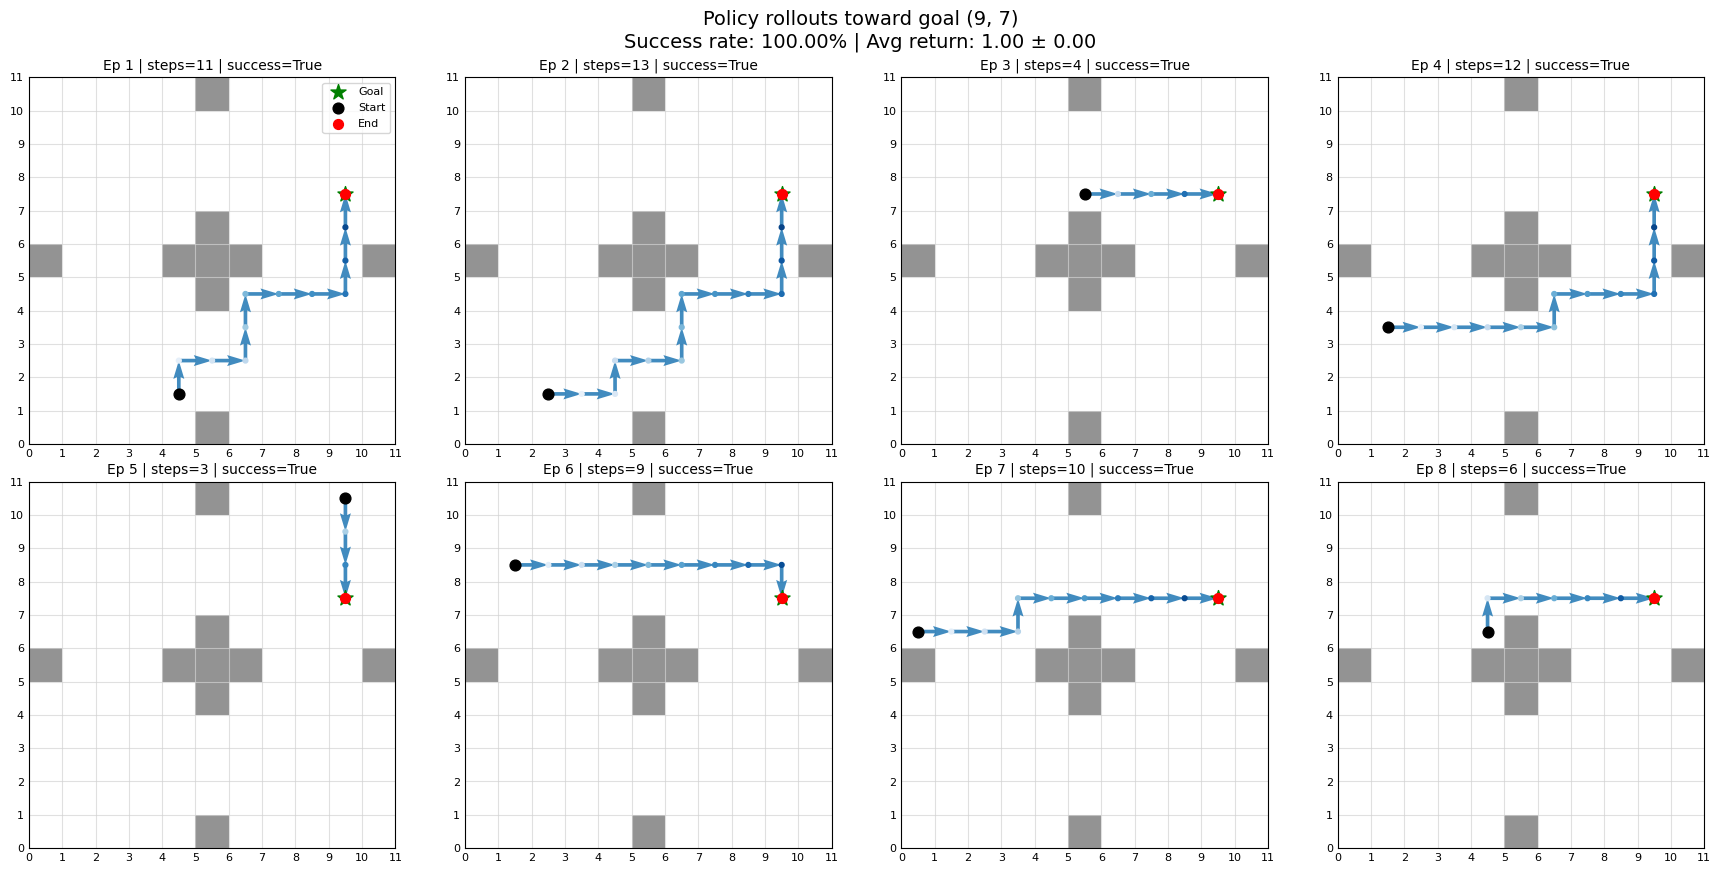

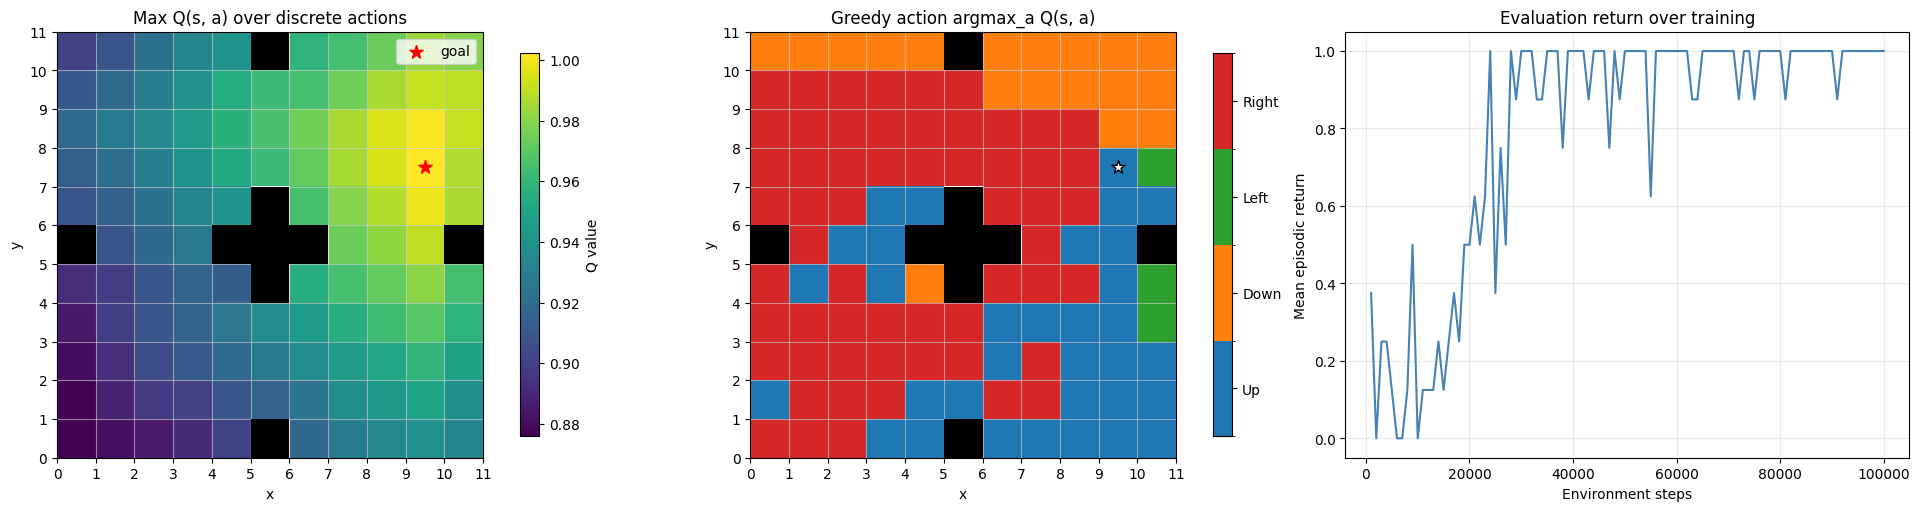

In [8]:
NEW_GOAL = (9, 7)

new_env = make_env(goal=NEW_GOAL)

q_target_new = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target_new.load_state_dict(q_net.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

for p in q_net.parameters():
    p.requires_grad_(False)

for p in q_net.net[-1].parameters():
    p.requires_grad_(True)


dqn_q_new, dqn_eval_new = dqn_train(env=new_env, q_network=dqn_q_first, q_target_network=q_target_new,goal=NEW_GOAL, params=q_net.net[-1].parameters())

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete) on top of pre-trained model')
    plt.grid(alpha=0.25)
    plt.show()


dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()


[DQN] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=500.0
[DQN] step=   2000 | eps=0.962 | eval_return=0.125 | eval_len=437.6
[DQN] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0
[DQN] step=   4000 | eps=0.924 | eval_return=0.125 | eval_len=437.6
[DQN] step=   5000 | eps=0.905 | eval_return=0.000 | eval_len=500.0
[DQN] step=   6000 | eps=0.886 | eval_return=1.000 | eval_len=6.2
[DQN] step=   7000 | eps=0.867 | eval_return=0.000 | eval_len=500.0
[DQN] step=   8000 | eps=0.848 | eval_return=1.000 | eval_len=8.1
[DQN] step=   9000 | eps=0.829 | eval_return=1.000 | eval_len=9.4
[DQN] step=  10000 | eps=0.810 | eval_return=1.000 | eval_len=6.6
[DQN] step=  11000 | eps=0.791 | eval_return=1.000 | eval_len=10.6
[DQN] step=  12000 | eps=0.772 | eval_return=0.875 | eval_len=66.9
[DQN] step=  13000 | eps=0.753 | eval_return=1.000 | eval_len=8.2
[DQN] step=  14000 | eps=0.734 | eval_return=1.000 | eval_len=8.5
[DQN] step=  15000 | eps=0.715 | eval_return=1.000 | eval_len=

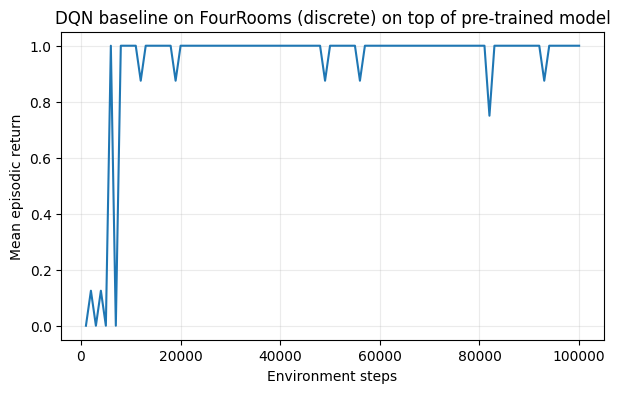

Episode 1: 10 steps | return: 1.00 | reached goal: True
Episode 2: 10 steps | return: 1.00 | reached goal: True
Episode 3: 11 steps | return: 1.00 | reached goal: True
Episode 4: 14 steps | return: 1.00 | reached goal: True
Episode 5: 13 steps | return: 1.00 | reached goal: True
Episode 6: 6 steps | return: 1.00 | reached goal: True
Episode 7: 1 steps | return: 1.00 | reached goal: True
Episode 8: 10 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


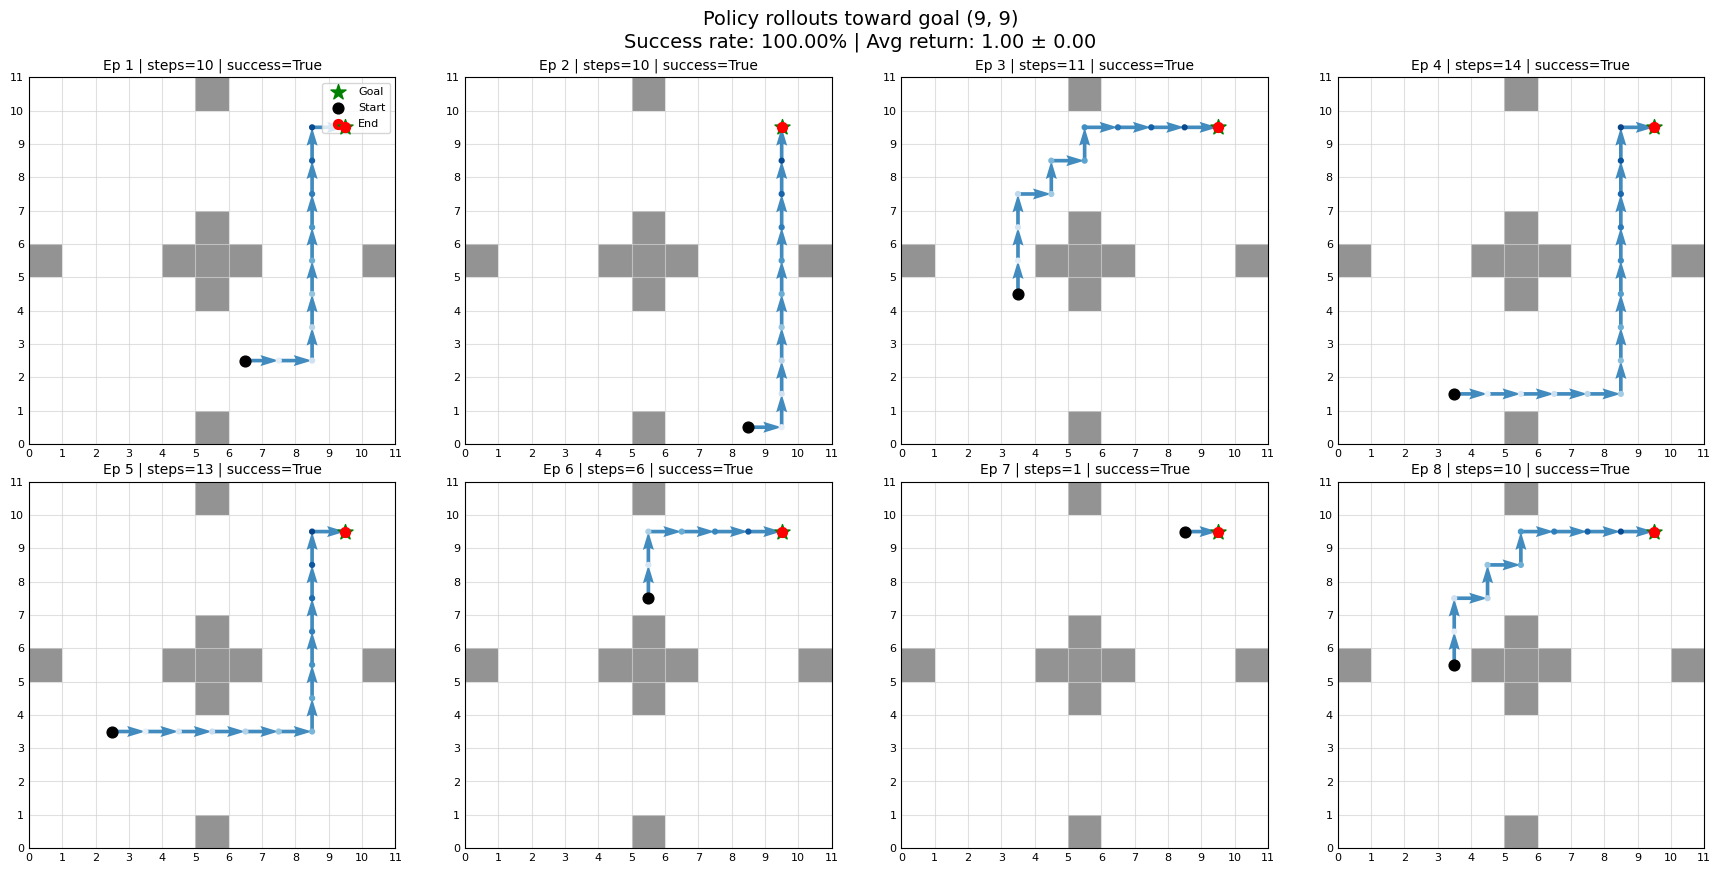

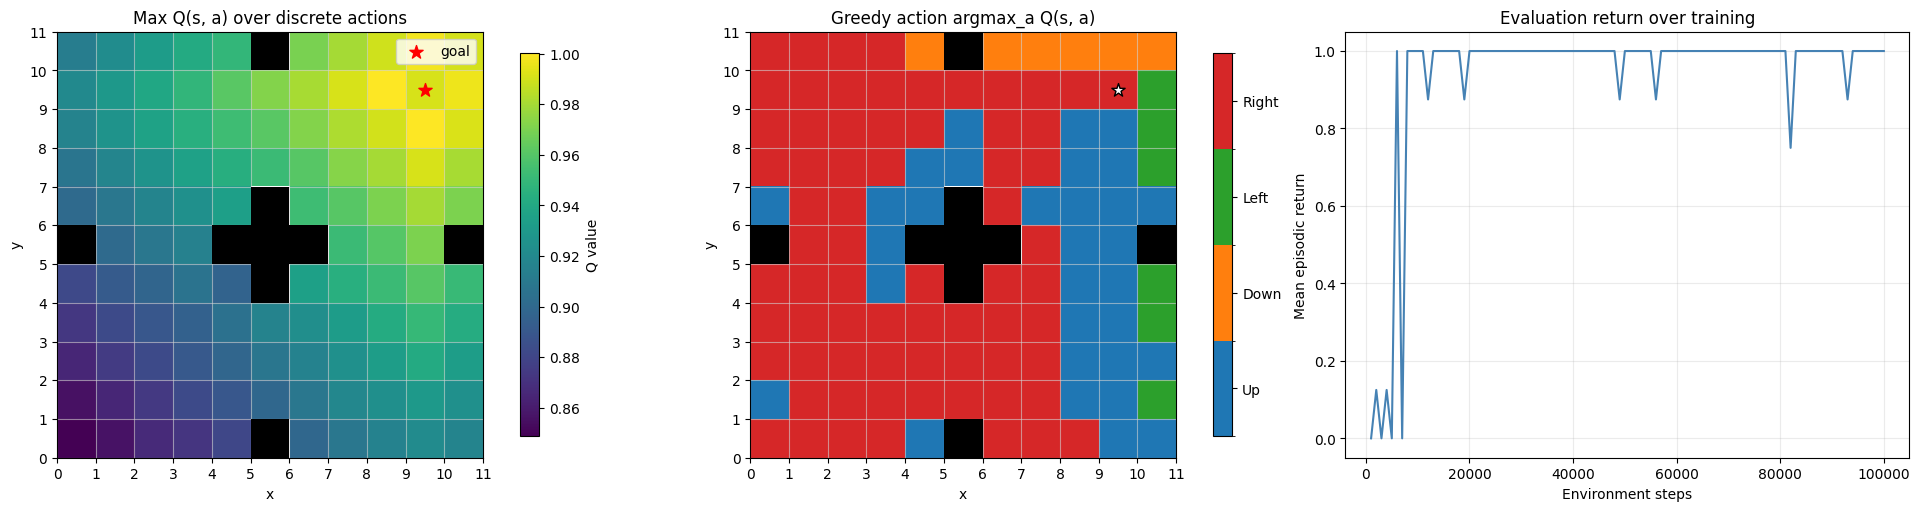

In [9]:
NEW_GOAL = (9, 9)

new_env = make_env(goal=NEW_GOAL)

q_target_new = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target_new.load_state_dict(q_net.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

for p in q_net.parameters():
    p.requires_grad_(False)

for p in q_net.net[-1].parameters():
    p.requires_grad_(True)


dqn_q_new, dqn_eval_new = dqn_train(env=new_env, q_network=dqn_q_first, q_target_network=q_target_new,goal=NEW_GOAL, params=q_net.net[-1].parameters())

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete) on top of pre-trained model')
    plt.grid(alpha=0.25)
    plt.show()


dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()
